Cell 1 – Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 – Load Cleaned Datasets

In [31]:
inventory = pd.read_csv("../data/cleaned/inventory.csv")
products = pd.read_csv("../data/cleaned/products.csv")
branches = pd.read_csv("../data/cleaned/branches.csv")
sales_header = pd.read_csv("../data/cleaned/sales_header.csv")
sales_lines = pd.read_csv("../data/cleaned/sales_lines.csv")

Cell 3 – Merge Inventory, Products and Branches

In [32]:
inventory_data = inventory.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("_inventory", "_product")
)

inventory_data = inventory_data.merge(
    branches,
    on="branch_id",
    how="left"
)

inventory_data.head()

,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month,branch_name,city,state,region,warehouse_type,warehouse_capacity,service_center_available,manager_id,total_employees,avg_monthly_revenue,monthly_operational_cost,market_demand_index
0,P001,Del001,196,59,46,340,115928,C15,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,Delhi Central,Delhi,Delhi,North,Central,45230 Sqft,Yes,9593,92,5234890,3189000,9
1,P001,Pun001,198,70,43,349,109389,D16,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,Pune Distribution,Pune,Maharashtra,West,Regional,38750 Sqft,Yes,6114,74,4389120,2654000,8
2,P001,Chn001,187,62,44,311,99373,A11,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,Chennai South Hub,Chennai,Tamil Nadu,South,Regional,41890 Sqft,Yes,7922,81,4567780,2739000,8
3,P001,Hyd001,226,71,65,417,108772,A10,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,Hyderabad Logistics,Hyderabad,Telangana,South,Branch,36210 Sqft,No,4390,57,3102455,1887000,7
4,P001,Kol001,263,94,58,475,103808,F03,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,Kolkata East Depot,Kolkata,West Bengal,East,Branch,29880 Sqft,No,5981,49,2894770,1743000,6


Cell 4 – Inventory Value

In [33]:
inventory_data["inventory_value"] = (
    inventory_data["current_stock"] *
    inventory_data["unit_cost"]
)

inventory_data[[
    "product_name",
    "current_stock",
    "inventory_value"
]].head()

,product_name,current_stock,inventory_value
0,Hydraulic Pump Hp-300,115928,2196835600
1,Hydraulic Pump Hp-300,109389,2072921550
2,Hydraulic Pump Hp-300,99373,1883118350
3,Hydraulic Pump Hp-300,108772,2061229400
4,Hydraulic Pump Hp-300,103808,1967161600


Cell 5 – Inventory Availability

In [34]:
inventory_data["availability_percent"] = (
    inventory_data["current_stock"] /
    inventory_data["max_stock"]
) * 100

inventory_data["availability_percent"] = inventory_data[
    "availability_percent"
].round(2)

inventory_data[[
    "product_name",
    "availability_percent"
]].head()

,product_name,availability_percent
0,Hydraulic Pump Hp-300,34096.47
1,Hydraulic Pump Hp-300,31343.55
2,Hydraulic Pump Hp-300,31952.73
3,Hydraulic Pump Hp-300,26084.41
4,Hydraulic Pump Hp-300,21854.32


Cell 6 – Availability Summary

In [35]:
availability = inventory_data[[
    "product_name",
    "availability_percent"
]].sort_values(
    by="availability_percent",
    ascending=False
)

availability.head(10)

,product_name,availability_percent
147,Cabin Glass Cg-20,85423.31
89,Engine Block Eb-600,80255.73
135,Idler Wheel Iw-55,78953.73
61,Hydraulic Cylinder Hc-200,78761.59
73,Seal Kit Sk-15,78361.65
114,Pivot Pin Pp-12,74542.86
158,O-Ring Set Or-50,73663.91
115,Pivot Pin Pp-12,73381.43
79,Transmission Assembly Ta-800,69137.80
71,Brake Pad Bp-40,68500.64


Cell 7 – Availability Chart

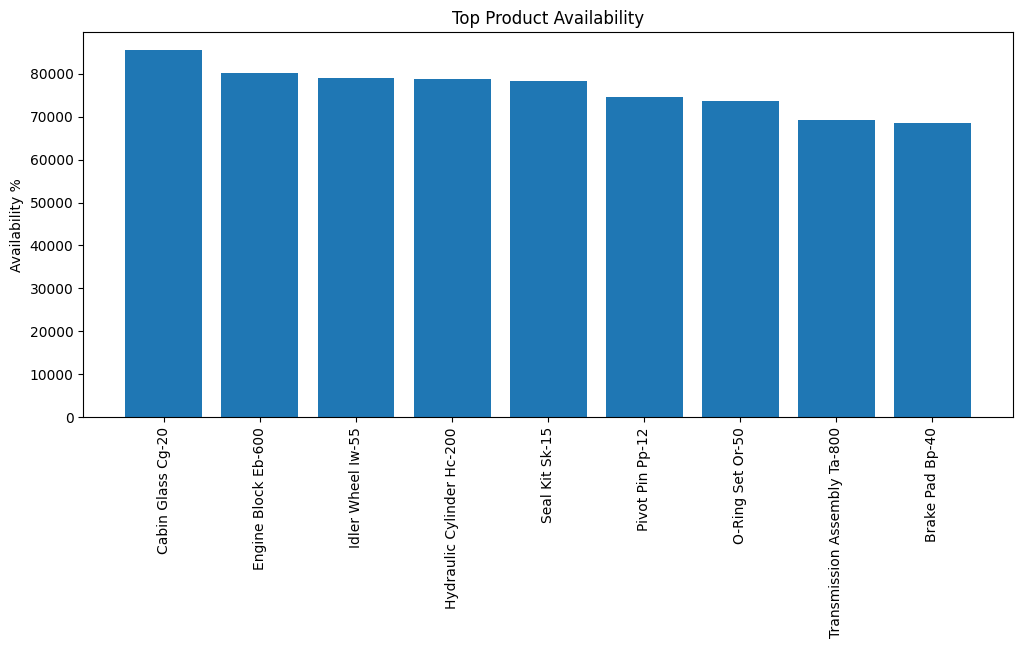

In [36]:
plt.figure(figsize=(12,5))

plt.bar(
    availability.head(10)["product_name"],
    availability.head(10)["availability_percent"]
)

plt.xticks(rotation=90)

plt.ylabel("Availability %")

plt.title("Top Product Availability")

plt.show()

Cell 8 – Stock Status Classification

In [37]:
conditions = [

    inventory_data["current_stock"] <
    inventory_data["safety_stock_inventory"],

    inventory_data["current_stock"] <
    inventory_data["reorder_level_inventory"],

    inventory_data["current_stock"] >
    inventory_data["max_stock"]

]

choices = [

    "Critical",

    "Understock",

    "Overstock"

]

inventory_data["stock_status"] = np.select(
    conditions,
    choices,
    default="Healthy"
)

inventory_data[[
    "product_name",
    "stock_status"
]].head()

,product_name,stock_status
0,Hydraulic Pump Hp-300,Overstock
1,Hydraulic Pump Hp-300,Overstock
2,Hydraulic Pump Hp-300,Overstock
3,Hydraulic Pump Hp-300,Overstock
4,Hydraulic Pump Hp-300,Overstock


Cell 9 – Stock Status Summary

In [38]:
stock_status = inventory_data["stock_status"].value_counts()

stock_status

stock_status
Overstock    180
Name: count, dtype: int64

Cell 10 – Stock Status Chart

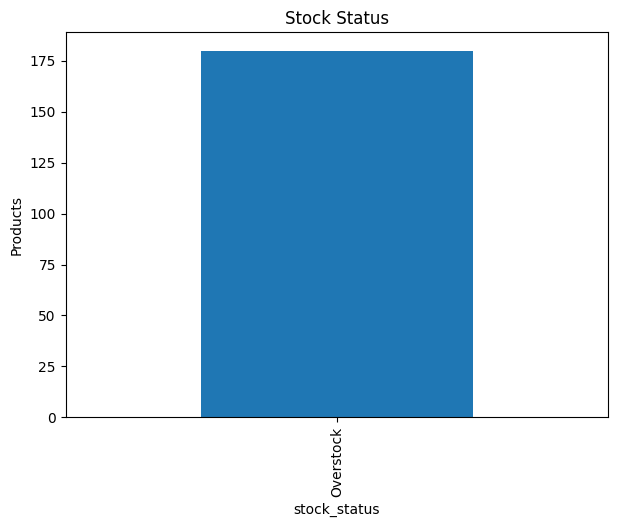

In [39]:
plt.figure(figsize=(7,5))

stock_status.plot(kind="bar")

plt.title("Stock Status")

plt.ylabel("Products")

plt.show()

Cell 11 – Inventory Value by Branch

In [40]:
branch_inventory = inventory_data.groupby(
    "branch_name"
)["inventory_value"].sum().sort_values(
    ascending=False
)

branch_inventory

branch_name
Chennai South Hub      47798163500
Pune Distribution      47728085910
Delhi Central          47709094440
Hyderabad Logistics    47224691630
Ahmedabad West Hub     46129795000
Kolkata East Depot     44702846930
Name: inventory_value, dtype: int64

Cell 12 – Branch Inventory Chart

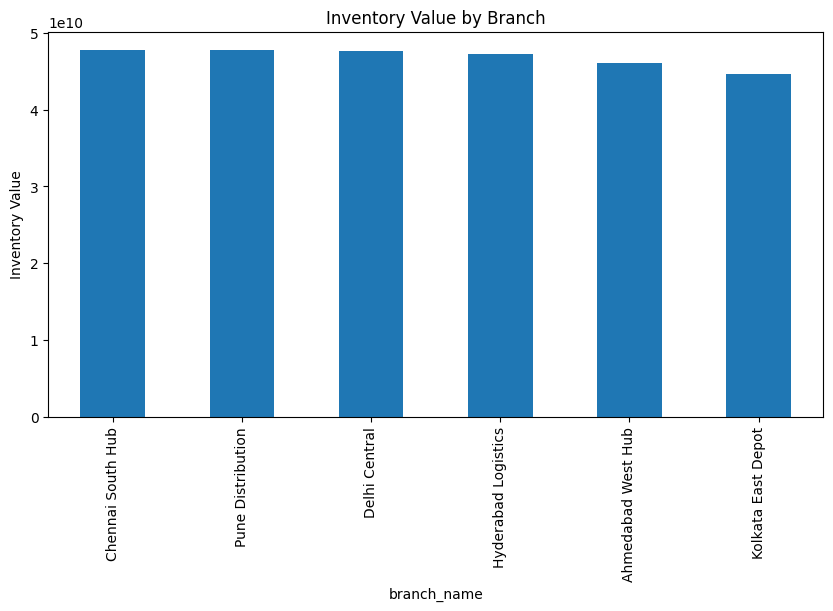

In [41]:
plt.figure(figsize=(10,5))

branch_inventory.plot(kind="bar")

plt.title("Inventory Value by Branch")

plt.ylabel("Inventory Value")

plt.show()

Cell 13 – Branch Summary

In [42]:
branch_summary = inventory_data.groupby(
    "branch_name"
).agg(

    Products=("product_id","count"),

    Current_Stock=("current_stock","sum"),

    Inventory_Value=("inventory_value","sum")

).reset_index()

branch_summary

,branch_name,Products,Current_Stock,Inventory_Value
0,Ahmedabad West Hub,30,3154992,46129795000
1,Chennai South Hub,30,3234245,47798163500
2,Delhi Central,30,3288670,47709094440
3,Hyderabad Logistics,30,3245291,47224691630
4,Kolkata East Depot,30,3123805,44702846930
5,Pune Distribution,30,3256263,47728085910


Cell 14 – Product Criticality Analysis

In [43]:
criticality = inventory_data["criticality_level"].value_counts()

criticality

criticality_level
High      96
Medium    66
Low       18
Name: count, dtype: int64

Cell 15 – Criticality Chart

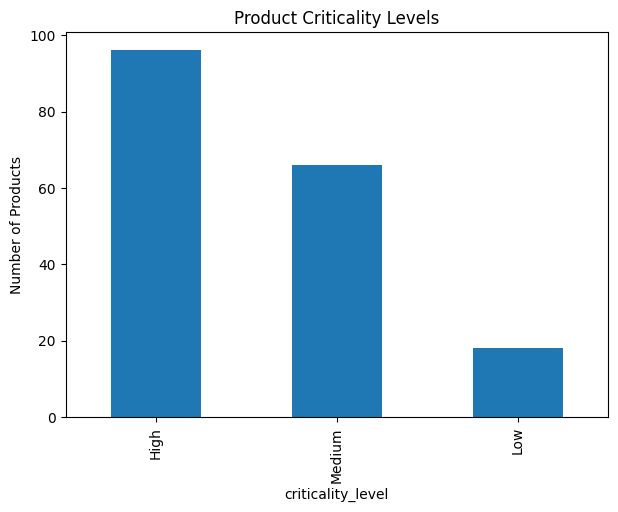

In [44]:
plt.figure(figsize=(7,5))

criticality.plot(kind="bar")

plt.title("Product Criticality Levels")

plt.ylabel("Number of Products")

plt.show()

Cell 16 – Inventory Value by Category

In [45]:
category_inventory = inventory_data.groupby(
    "category"
)["inventory_value"].sum().sort_values(
    ascending=False
)

category_inventory

category
Engine           94074806700
Hydraulic        76980735240
Transmission     45323915500
Undercarriage    37039171200
Electrical       13738763250
Cooling           4944888000
Cabin             3649973600
Sensors           1746189500
Brakes            1193592600
Filters            827849700
Seals              766908660
Pins & Bushes      468949500
Attachments        212395960
Belts              210901120
Lubricants         113636880
Name: inventory_value, dtype: int64

Cell 17 – Category Inventory Chart

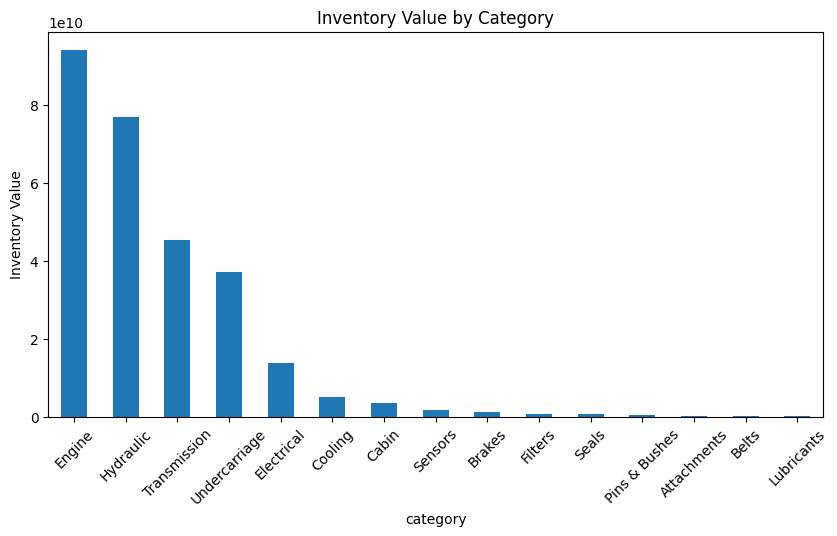

In [46]:
plt.figure(figsize=(10,5))

category_inventory.plot(kind="bar")

plt.title("Inventory Value by Category")

plt.ylabel("Inventory Value")

plt.xticks(rotation=45)

plt.show()

Cell 18 – Average Stock by Category

In [47]:
avg_stock = inventory_data.groupby(
    "category"
)["current_stock"].mean().sort_values(
    ascending=False
)

avg_stock

category
Brakes           110517.833333
Transmission     110277.166667
Belts            109844.333333
Filters          108760.583333
Cabin            108630.166667
Undercarriage    108626.875000
Engine           107705.875000
Hydraulic        106983.611111
Sensors          105829.666667
Electrical       105741.166667
Cooling          105660.000000
Seals            105464.250000
Lubricants       105219.333333
Pins & Bushes    104211.000000
Attachments      104115.666667
Name: current_stock, dtype: float64

Cell 19 – Average Stock Chart

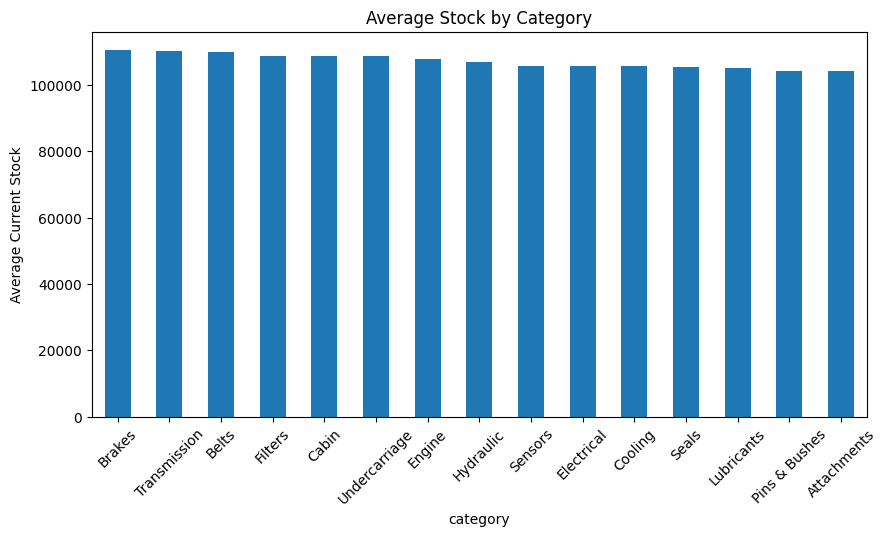

In [48]:
plt.figure(figsize=(10,5))

avg_stock.plot(kind="bar")

plt.title("Average Stock by Category")

plt.ylabel("Average Current Stock")

plt.xticks(rotation=45)

plt.show()

Cell 20 – Warehouse Utilization

In [49]:
inventory_data["warehouse_utilization"] = (
    inventory_data["current_stock"] /
    inventory_data["max_stock"]
) * 100

inventory_data["warehouse_utilization"] = inventory_data[
    "warehouse_utilization"
].round(2)

inventory_data[[
    "branch_name",
    "product_name",
    "warehouse_utilization"
]].head()

,branch_name,product_name,warehouse_utilization
0,Delhi Central,Hydraulic Pump Hp-300,34096.47
1,Pune Distribution,Hydraulic Pump Hp-300,31343.55
2,Chennai South Hub,Hydraulic Pump Hp-300,31952.73
3,Hyderabad Logistics,Hydraulic Pump Hp-300,26084.41
4,Kolkata East Depot,Hydraulic Pump Hp-300,21854.32


Cell 21 – Branch Performance Score

In [50]:
branch_score = inventory_data.groupby("branch_name").agg(
    Inventory_Value=("inventory_value", "sum"),
    Avg_Utilization=("warehouse_utilization", "mean"),
    Critical_Products=("stock_status", lambda x: (x == "Critical").sum())
).reset_index()

branch_score["Performance_Score"] = (
    branch_score["Inventory_Value"] * 0.0001 +
    branch_score["Avg_Utilization"] * 0.5 -
    branch_score["Critical_Products"] * 5
)

branch_score = branch_score.sort_values(
    by="Performance_Score",
    ascending=False
)

branch_score

,branch_name,Inventory_Value,Avg_Utilization,Critical_Products,Performance_Score
1,Chennai South Hub,47798163500,38545.863000,0,4.799089e+06
5,Pune Distribution,47728085910,43763.136000,0,4.794690e+06
2,Delhi Central,47709094440,38094.464333,0,4.789957e+06
3,Hyderabad Logistics,47224691630,39318.277667,0,4.742128e+06
0,Ahmedabad West Hub,46129795000,38603.953333,0,4.632281e+06
4,Kolkata East Depot,44702846930,32698.262667,0,4.486634e+06


Cell 22 – Branch Performance Chart

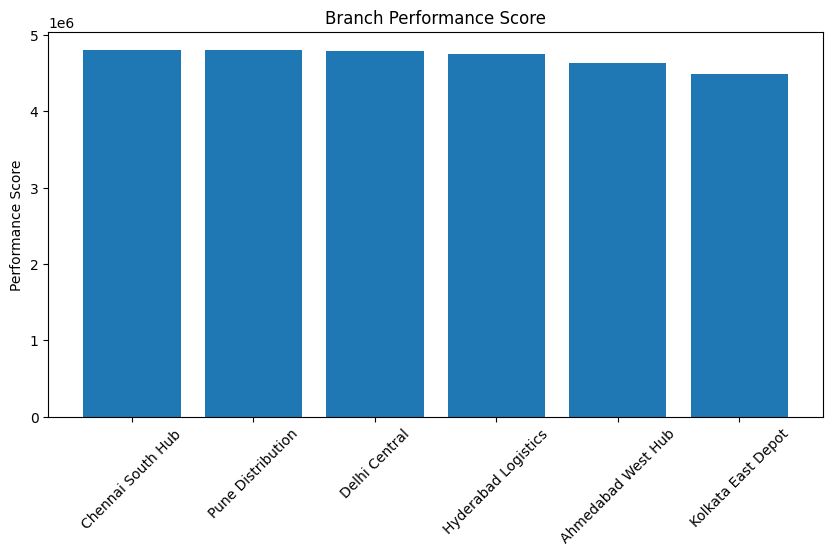

In [51]:
plt.figure(figsize=(10,5))

plt.bar(
    branch_score["branch_name"],
    branch_score["Performance_Score"]
)

plt.xticks(rotation=45)

plt.title("Branch Performance Score")

plt.ylabel("Performance Score")

plt.show()

Cell 23 – Operational Risk Dashboard

In [52]:
risk_dashboard = pd.DataFrame({

    "Metric":[
        "Critical Products",
        "Understock Products",
        "Healthy Products",
        "Overstock Products"
    ],

    "Count":[
        (inventory_data["stock_status"]=="Critical").sum(),
        (inventory_data["stock_status"]=="Understock").sum(),
        (inventory_data["stock_status"]=="Healthy").sum(),
        (inventory_data["stock_status"]=="Overstock").sum()
    ]

})

risk_dashboard

,Metric,Count
0,Critical Products,0
1,Understock Products,0
2,Healthy Products,0
3,Overstock Products,180


Cell 24 – KPI Dashboard

In [53]:
kpi = pd.DataFrame({

    "KPI":[
        "Total Inventory Value",
        "Average Warehouse Utilization",
        "Branches",
        "Products",
        "Healthy Products",
        "Critical Products"
    ],

    "Value":[
        round(inventory_data["inventory_value"].sum(),2),
        round(inventory_data["warehouse_utilization"].mean(),2),
        inventory_data["branch_id"].nunique(),
        inventory_data["product_id"].nunique(),
        (inventory_data["stock_status"]=="Healthy").sum(),
        (inventory_data["stock_status"]=="Critical").sum()
    ]

})

kpi

,KPI,Value
0,Total Inventory Value,2.812927e+11
1,Average Warehouse Utilization,3.850399e+04
2,Branches,6.000000e+00
3,Products,3.000000e+01
4,Healthy Products,0.000000e+00
5,Critical Products,0.000000e+00


Cell 25 – Top 10 Products by Inventory Value

In [54]:
top_products = inventory_data.sort_values(
    by="inventory_value",
    ascending=False
)

top_products[[
    "product_name",
    "branch_name",
    "inventory_value"
]].head(10)

,product_name,branch_name,inventory_value
86,Engine Block Eb-600,Chennai South Hub,10872770500
87,Engine Block Eb-600,Hyderabad Logistics,10508342500
85,Engine Block Eb-600,Pune Distribution,10127584000
89,Engine Block Eb-600,Ahmedabad West Hub,10040392500
84,Engine Block Eb-600,Delhi Central,9642348500
88,Engine Block Eb-600,Kolkata East Depot,9220238500
80,Transmission Assembly Ta-800,Chennai South Hub,7829687000
79,Transmission Assembly Ta-800,Pune Distribution,7766941000
78,Transmission Assembly Ta-800,Delhi Central,7625488500
81,Transmission Assembly Ta-800,Hyderabad Logistics,7625077500


Cell 26 – Top 10 Inventory Value Chart

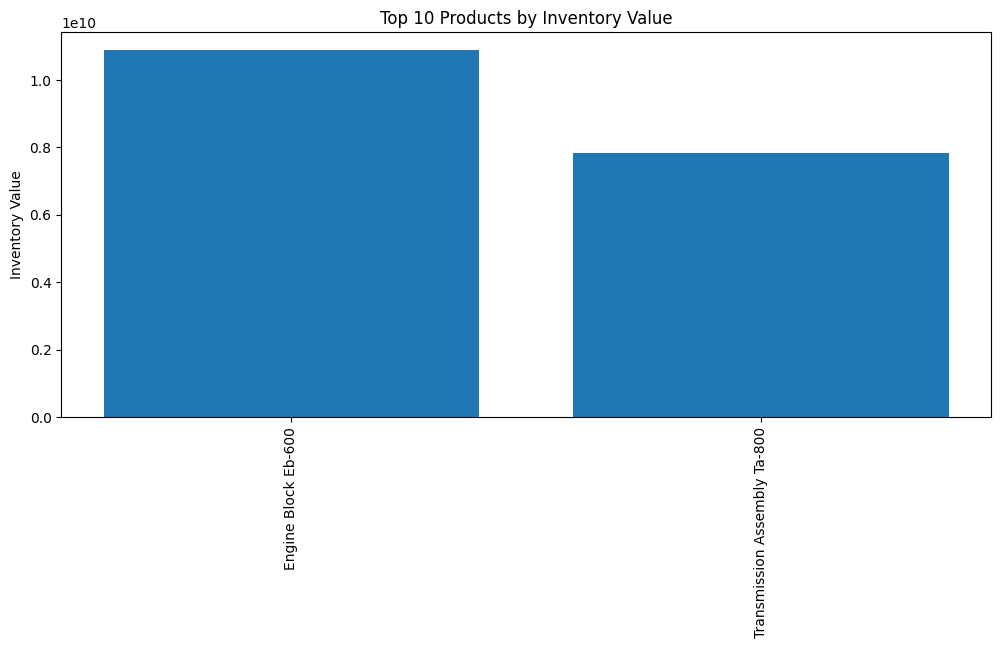

In [55]:
plt.figure(figsize=(12,5))

plt.bar(
    top_products.head(10)["product_name"],
    top_products.head(10)["inventory_value"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Products by Inventory Value")

plt.ylabel("Inventory Value")

plt.show()

Cell 27 – Business Insights

In [56]:
print("="*70)
print("BUSINESS INSIGHTS")
print("="*70)

print(f"Total Inventory Value : ₹{inventory_data['inventory_value'].sum():,.2f}")

print(f"Average Warehouse Utilization : {inventory_data['warehouse_utilization'].mean():.2f}%")

print(f"Total Products : {inventory_data['product_id'].nunique()}")

print(f"Total Branches : {inventory_data['branch_id'].nunique()}")

print(f"Healthy Products : {(inventory_data['stock_status']=='Healthy').sum()}")

print(f"Critical Products : {(inventory_data['stock_status']=='Critical').sum()}")

print(f"Understock Products : {(inventory_data['stock_status']=='Understock').sum()}")

print(f"Overstock Products : {(inventory_data['stock_status']=='Overstock').sum()}")

BUSINESS INSIGHTS
Total Inventory Value : ₹281,292,677,410.00
Average Warehouse Utilization : 38503.99%
Total Products : 30
Total Branches : 6
Healthy Products : 0
Critical Products : 0
Understock Products : 0
Overstock Products : 180


Cell 28 – Business Recommendations

In [57]:
recommendations = [

    "Maintain adequate stock for critical products.",

    "Reduce overstock inventory to lower holding costs.",

    "Monitor warehouse utilization regularly.",

    "Improve inventory planning for understock products.",

    "Focus on high-value inventory categories.",

    "Improve branch performance through inventory optimization."

]

print("BUSINESS RECOMMENDATIONS")
print("-"*60)

for i, rec in enumerate(recommendations,1):
    print(f"{i}. {rec}")

BUSINESS RECOMMENDATIONS
------------------------------------------------------------
1. Maintain adequate stock for critical products.
2. Reduce overstock inventory to lower holding costs.
3. Monitor warehouse utilization regularly.
4. Improve inventory planning for understock products.
5. Focus on high-value inventory categories.
6. Improve branch performance through inventory optimization.


Cell 29 – Final KPI Summary

In [58]:
summary = pd.DataFrame({

    "Analysis":[

        "Inventory Value",

        "Availability Analysis",

        "Stock Status",

        "Category Analysis",

        "Criticality Analysis",

        "Warehouse Utilization",

        "Branch Performance",

        "Operational Risk Dashboard"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

summary

,Analysis,Status
0,Inventory Value,Completed
1,Availability Analysis,Completed
2,Stock Status,Completed
3,Category Analysis,Completed
4,Criticality Analysis,Completed
5,Warehouse Utilization,Completed
6,Branch Performance,Completed
7,Operational Risk Dashboard,Completed
